In [ ]:
# %%

import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from IPython.display import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [ ]:
# %%

mg = pd.read_csv("magic04.data")
mg
mg.columns = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist",
    "class",
]
mg

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
1,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
2,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
3,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
4,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.0980,g
...,...,...,...,...,...,...,...,...,...,...,...
19014,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19015,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19016,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19017,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


In [ ]:
# %% Convert class to int

mg.loc[:, "class"] = (mg["class"] == "g").astype(int)
mg["class"] = pd.to_numeric(mg["class"], errors="coerce")
# Here though values get set to 0-1, the column well
# still have the object form so change the type to int!
# There will be errors later in fitting models!
mg.iloc[:, -1]

# mg["class"].unique()
# (mg["class"] == "g")  # This is a true/false pandas series.
# mg.loc[:, "class"]  # this is a pandas series.
# # y[(y['class']=='g')].astype(int) #This is another way

0        1
1        1
2        1
3        1
4        1
        ..
19014    0
19015    0
19016    0
19017    0
19018    0
Name: class, Length: 19019, dtype: int64

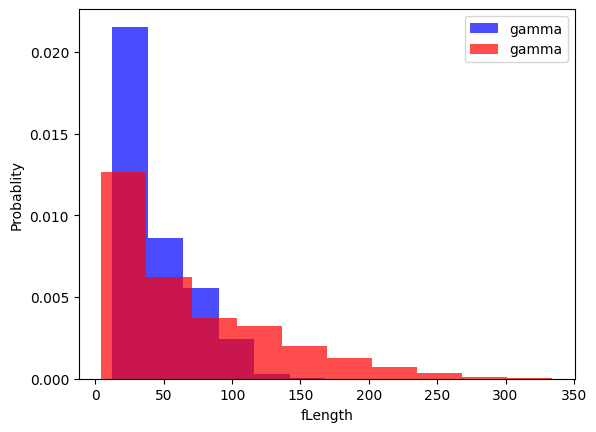

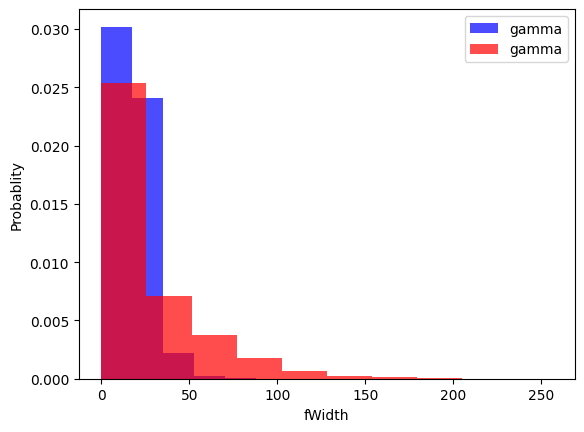

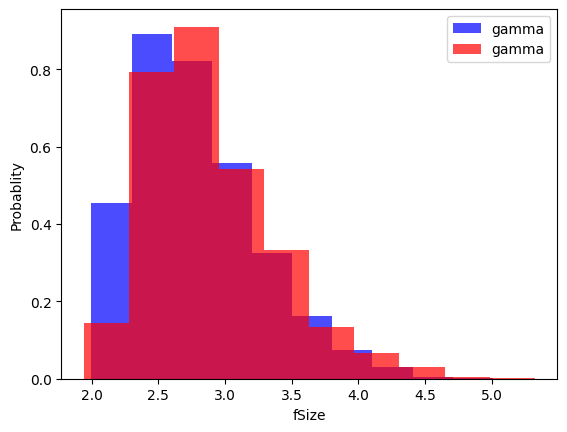

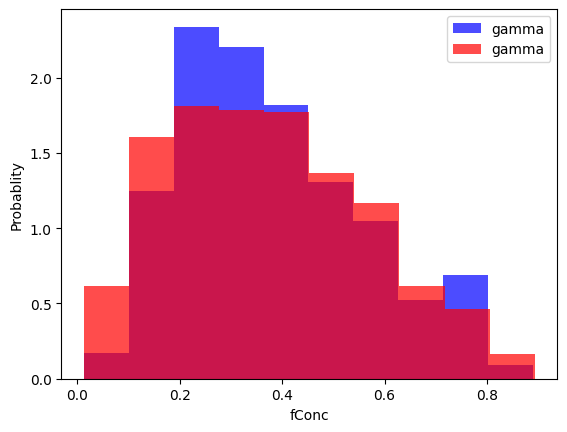

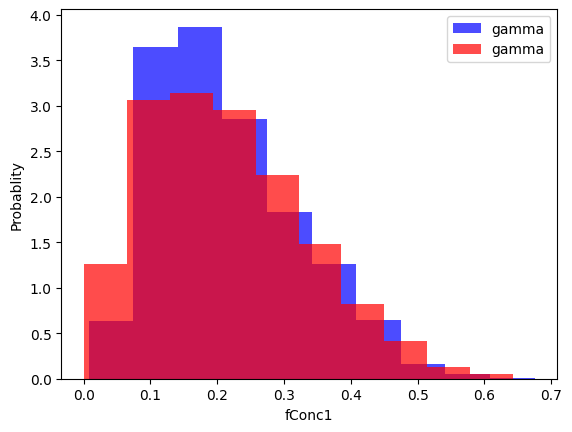

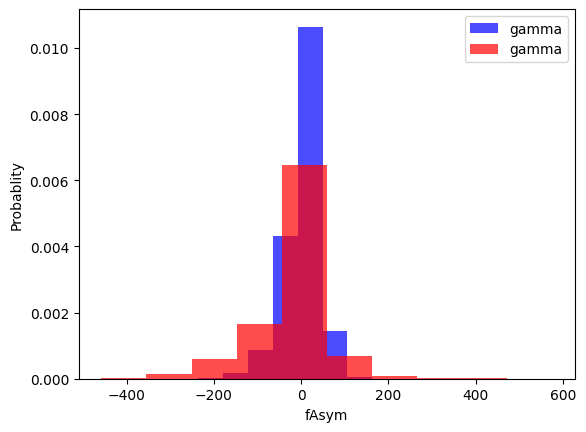

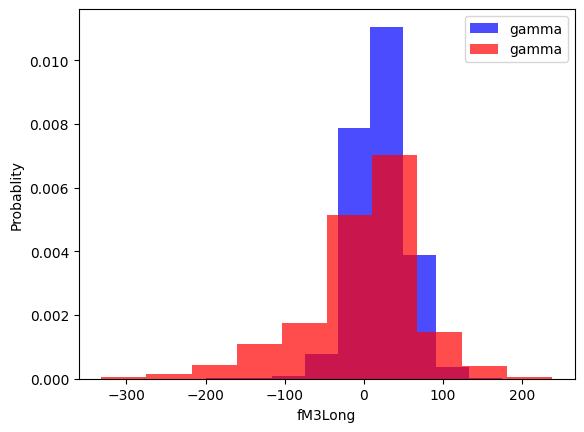

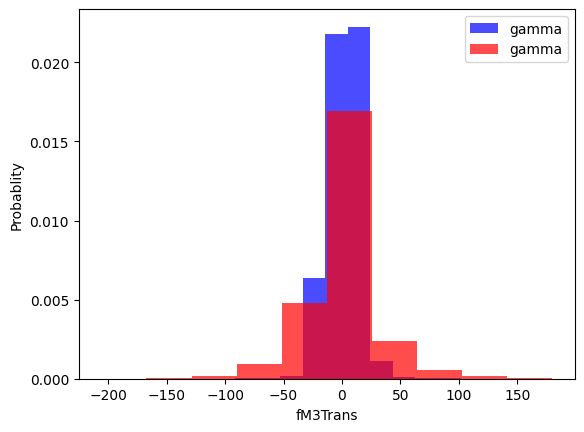

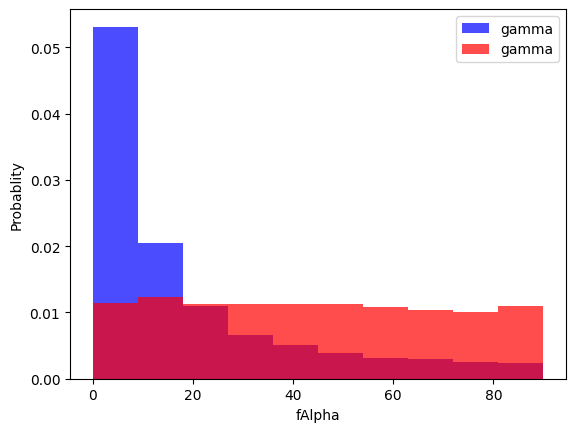

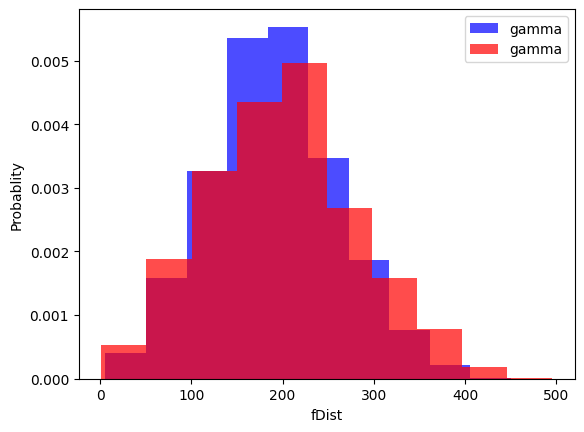

In [ ]:
# %% plot the columns to compare

# plt.hist(mg['fLength'],density=True,)
for label in mg.columns[:-1]:
    plt.hist(
        mg[mg["class"] == 1][label],
        density=True,
        color="blue",
        label="gamma",
        alpha=0.7,
    )
    plt.hist(
        mg[mg["class"] == 0][label], density=True, color="Red", label="gamma", alpha=0.7
    )
    plt.ylabel("Probablity")
    plt.xlabel(label)
    plt.legend()
    plt.show()

In [ ]:
# %% train test splitting

mg.sample(frac=1)  # shuffles the data
X = mg.iloc[:, :-1]
y = mg.iloc[:, -1]
type(mg.iloc[:, -1])

pandas.core.series.Series

In [ ]:
# %%

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=0
)

In [ ]:
# %% Standardize the X set because some values are extremely large

x = StandardScaler()
X = x.fit_transform(X)

In [ ]:
# %% Data us imbalanced

print("Number of zeros:", len(mg[mg["class"] == 0]))
print("Number of ones:", len(mg[mg["class"] == 1]))

Number of zeros: 6688
Number of ones: 12331


In [ ]:
# %% We need to balance the data

# y_train = y_train.astype('int')
print("Before Sampling:")
print(y_train.value_counts())
res = RandomOverSampler(random_state=0)
X_train, y_train = res.fit_resample(X_train, y_train)
print("------------------------------")
print("After Sampling:")
print(y_train.value_counts())

Before Sampling:
class
1    7399
0    4012
Name: count, dtype: int64
------------------------------
After Sampling:
class
0    7399
1    7399
Name: count, dtype: int64


In [ ]:
# %% KNN Model

for i in [5, 6, 7, 13, 15, 19, 20, 25, 27, 30, 32]:
    knn_model = KNeighborsClassifier(n_neighbors=i)
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)
    print("N=", i)
    print(classification_report(y_true=y_test, y_pred=y_pred))
    print("\n------------------------------")

N= 5
              precision    recall  f1-score   support

           0       0.67      0.67      0.67      1366
           1       0.82      0.81      0.81      2438

    accuracy                           0.76      3804
   macro avg       0.74      0.74      0.74      3804
weighted avg       0.76      0.76      0.76      3804


------------------------------
N= 6
              precision    recall  f1-score   support

           0       0.63      0.73      0.68      1366
           1       0.83      0.76      0.80      2438

    accuracy                           0.75      3804
   macro avg       0.73      0.74      0.74      3804
weighted avg       0.76      0.75      0.75      3804


------------------------------
N= 7
              precision    recall  f1-score   support

           0       0.70      0.68      0.69      1366
           1       0.82      0.83      0.83      2438

    accuracy                           0.78      3804
   macro avg       0.76      0.76      0.76      

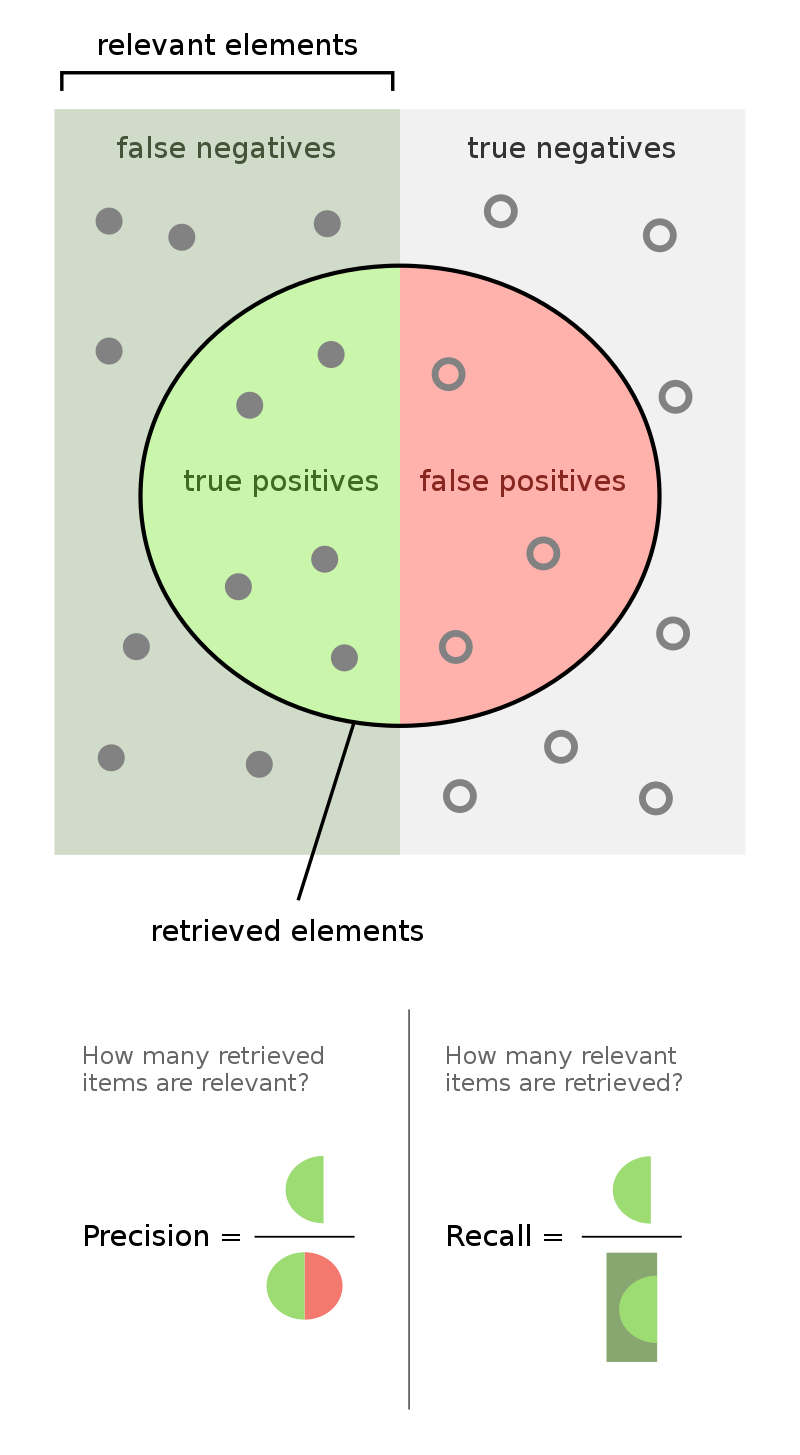

In [ ]:
# %% Precision and Recall

# https://en.wikipedia.org/wiki/Precision_and_recall?oldformat=true

image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/800px-Precisionrecall.svg.png"  # Replace with your image URL
urllib.request.urlretrieve(image_url, "downloaded_image.jpg")  # Download the image

# Display the image in your notebook
display(Image(filename="downloaded_image.jpg"))

# Image(url="https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/800px-Precisionrecall.svg.png") #This is enough

In [ ]:
# %% NAIVE BAYES MODEL

bayes_model = GaussianNB()
bayes_model.fit(X_train, y_train)
y_pred = bayes_model.predict(X_test)
print("Gaussian Naive Bayes")
print(classification_report(y_true=y_test, y_pred=y_pred))

Gaussian Naive Bayes
              precision    recall  f1-score   support

           0       0.70      0.43      0.53      1366
           1       0.74      0.90      0.81      2438

    accuracy                           0.73      3804
   macro avg       0.72      0.66      0.67      3804
weighted avg       0.72      0.73      0.71      3804



In [ ]:
# %% LOGISTIC REGRESSION MODEL

lg_model = LogisticRegression(max_iter=1000)
lg_model.fit(X_train, y_train)
y_pred = lg_model.predict(X_test)
print("Logistic Regression")
print(classification_report(y_true=y_test, y_pred=y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      1366
           1       0.84      0.82      0.83      2438

    accuracy                           0.79      3804
   macro avg       0.77      0.77      0.77      3804
weighted avg       0.79      0.79      0.79      3804



In [ ]:
# %% SVM MODEL

svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print("SVM")
print(classification_report(y_true=y_test, y_pred=y_pred))

SVM
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1366
           1       0.84      0.86      0.85      2438

    accuracy                           0.81      3804
   macro avg       0.80      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804

